In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [5]:
import zipfile
zip_path = r'C:\Users\user\OneDrive\Desktop\pandas\Online Retail.xlsx.zip'
extract_path = r'C:\Users\user\OneDrive\Desktop\pandas'

In [6]:
with zipfile.ZipFile(zip_path,'r')as zip_ref:
    zip_ref.extractall(extract_path)

In [11]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
df = pd.read_excel(r'C:\Users\user\OneDrive\Desktop\pandas\Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df['Description'] = df['Description'].fillna('Unknown')
df['CustomerID'] = df['CustomerID'].fillna(0)

In [19]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [20]:
for col in ['Quantity','UnitPrice']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1 -1.5*IQR 
    upper_bound= q3 + 1.5*IQR
    df = df[(df[col]>= lower_bound) & (df[col]<= upper_bound)]

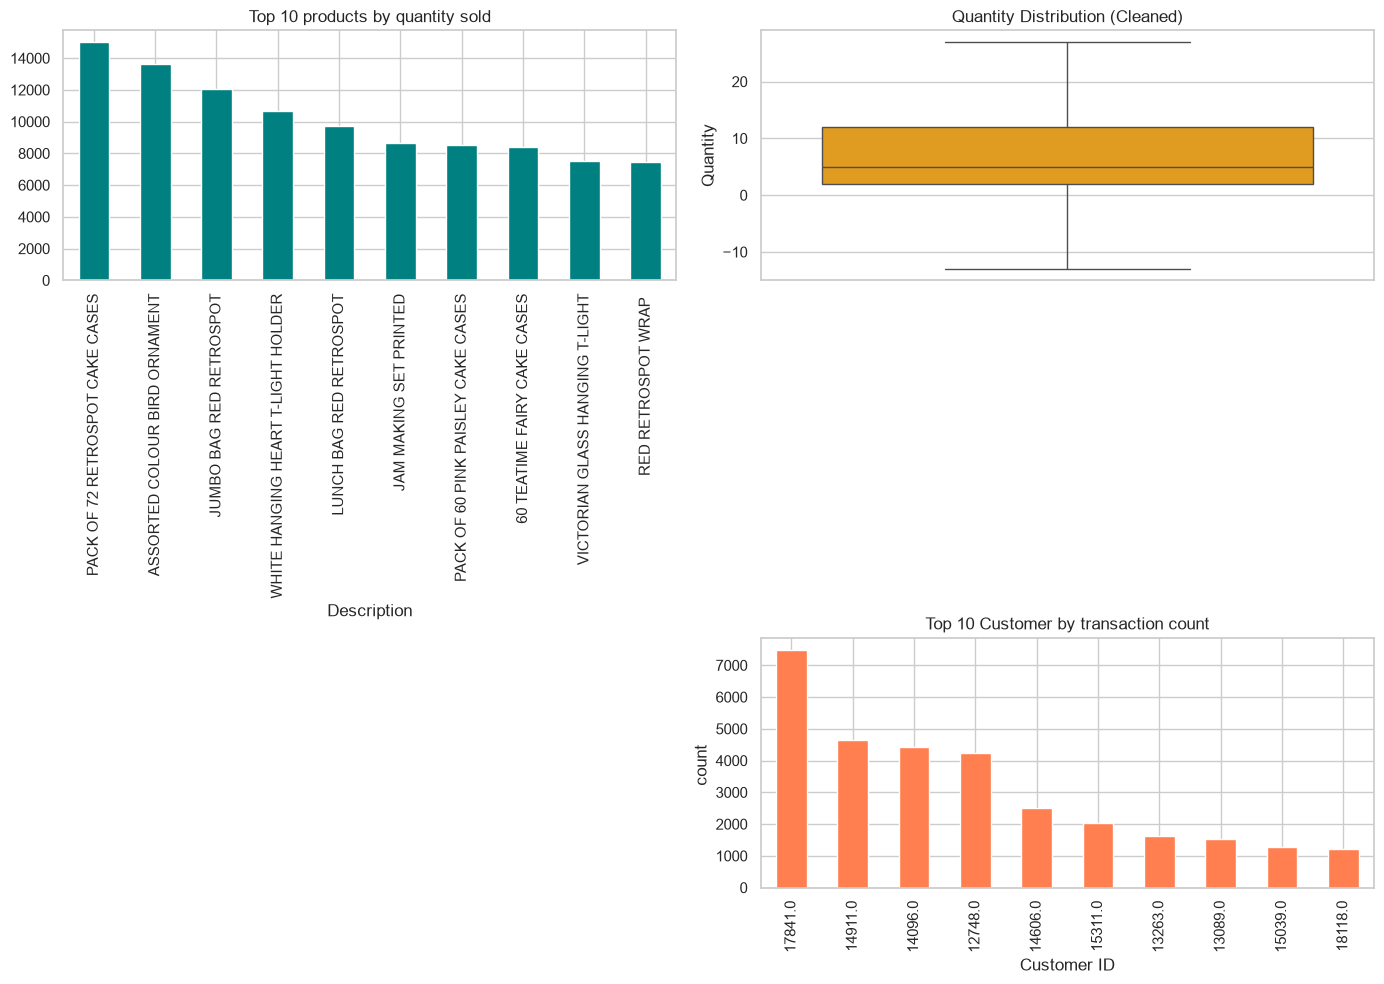

In [25]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
top_products = df.groupby('Description')['Quantity'].sum().nlargest(10)
top_products.plot(kind='bar', color='teal')
plt.title('Top 10 products by quantity sold')

plt.subplot(2,2,2)
sns.boxplot(y=df['Quantity'],color='orange')
plt.title('Quantity Distribution (Cleaned)')
plt.ylabel('Quantity')

plt.subplot(2,2,4)
top_customers=(
    df[df['CustomerID']!=0]['CustomerID'].astype(str).value_counts().head(10)
)
top_customers.plot(kind='bar',color='coral')
plt.title('Top 10 Customer by transaction count')
plt.xlabel('Customer ID')
plt.ylabel('count ')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd


In [27]:
customer_df = (
    df[df['CustomerID'] != 0]
    .groupby('CustomerID')
    .agg(
        {
            'Quantity': 'sum',  # إجمالي الكمية المشتراة
            'InvoiceNo': 'count',  # عدد مرات الشراء (Frequency)
            'UnitPrice': 'mean',  # متوسط السعر
        }
    )
    .reset_index()
)

In [28]:

X = customer_df[['Quantity', 'InvoiceNo', 'UnitPrice']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)


In [30]:

customer_df['Cluster'] = cluster_labels

In [31]:

score = silhouette_score(X_scaled, cluster_labels)
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.4371


In [35]:
for k in range(2, 7):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  print(f'Clusters: {k} -> Silhouette Score: {silhouette_score(X_scaled, labels):.4f}')

Clusters: 2 -> Silhouette Score: 0.9482
Clusters: 3 -> Silhouette Score: 0.3725
Clusters: 4 -> Silhouette Score: 0.4371
Clusters: 5 -> Silhouette Score: 0.3727
Clusters: 6 -> Silhouette Score: 0.3988
